In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sheets = pd.read_excel(r"D:\Chrome downloads new\Regional+Sales+Summary (1)\Regional Sales Summary\Regional Sales Dataset.xlsx", sheet_name=None)


In [3]:
# view all sheets names on the file
print(sheets.keys())

dict_keys(['Sales Orders', 'Customers', 'Regions', 'State Regions', 'Products', '2017 Budgets'])


In [4]:
# Assign to named DataFrames

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_regions = sheets['Regions']
df_state_regions = sheets['State Regions']
df_products = sheets['Products']
df_budget = sheets['2017 Budgets']

## Data Profiling

In [5]:
# QUICK SHAPE OVERVIEW
print(f"df_sales      shape: {df_sales.shape}      # Sales Orders")
print(f"df_customers  shape: {df_customers.shape}  # Customers")
print(f"df_products   shape: {df_products.shape}   # Products")
print(f"df_regions    shape: {df_regions.shape}    # Regions")
print(f"df_state_reg  shape: {df_state_regions.shape}  # State Regions")
print(f"df_budgets    shape: {df_budget.shape}    # 2017 Budgets")

df_sales      shape: (64104, 12)      # Sales Orders
df_customers  shape: (175, 2)  # Customers
df_products   shape: (30, 2)   # Products
df_regions    shape: (994, 15)    # Regions
df_state_reg  shape: (49, 3)  # State Regions
df_budgets    shape: (30, 2)    # 2017 Budgets


In [6]:
# QUICK VIEW OF ALL RAW DATAFRAMES

# Print first few rows for each sheet

print("\n— df_sales head —")
display(df_sales.head())
print()

print("\n— df_customers head —")
display(df_customers.head())
print()

print("\n— df_products head —")
display(df_products.head())
print()

print("\n— df_regions head —")
display(df_regions.head())
print()

print("\n— df_state_reg head —")
display(df_state_regions.head())
print()

print("\n— df_budgets head —")
display(df_budget.head())



— df_sales head —


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270




— df_customers head —


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd




— df_products head —


...

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago




— df_state_reg head —


,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West




— df_budgets head —


,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [7]:
# The first row of df_state_regions contains the real column names.

# The first row of df_state_reg contains the real column names.
new_header        = df_state_regions.iloc[0]      # grab the first row
df_state_regions.columns = new_header             # set columns
df_state_reg       = df_state_regions[1:].reset_index(drop=True)  # drop header row and reset

In [8]:
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [9]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [10]:
# Checking duplicate values
len(df_sales) == len(df_sales.drop_duplicates())

True

## Data Cleaning & Wrangling


In [11]:
# DATA WRANGLING & MERGING

#  Merge with Customers
df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

# Merge with Products
df = df.merge(
    df_products,
    how='left', 
    left_on='Product Description Index',
    right_on='Index'
)

# Merge with Regions
df = df.merge(
    df_regions,
    left_on='Delivery Region Index',
    right_on='id'
)

# Merge with State Regions
df = df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

# Merge with Budgets
df = df.merge(
    df_budget,
    how='left',
    on='Product Name'
)


In [12]:
# Clean up redundant columns
cols_to_drop = [
    'Customer Index', 'Index', 'id', 'State Code'
]
df = df.drop(columns=cols_to_drop, errors='ignore')
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [13]:
df.columns = df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [14]:
#  DROP UNNECESSARY COLUMNS & RENAME FOR CLARITY (with Region)
# ------------------------------------------------------------------

# 1) List only the columns you want to KEEP, now including the broader 'region'
cols_to_keep = [
    'ordernumber',        # unique order ID
    'orderdate',          # date when the order was placed
    'customer names',     # customer who placed the order
    'channel',            # sales channel (e.g., Wholesale, Distributor)
    'product name',       # product purchased
    'order quantity',     # number of units ordered
    'unit price',         # price per unit
    'line total',         # revenue for this line item (qty × unit_price)
    'total unit cost',    # company’s cost for this line item
    'state_code',         # two-letter state code
    'state',              # full state name
    'region',             # broader U.S. region (e.g., South, West)
    'latitude',           # latitude of delivery city
    'longitude',          # longitude of delivery city
    '2017 budgets'        # budget target for this product in 2017
]

df = df[cols_to_keep]

# 2) Rename to more Pythonic / self-explanatory names, including region
df = df.rename(columns={
    'ordernumber'      : 'order_number',   
    'orderdate'        : 'order_date',    
    'customer names'   : 'customer_name',  
    'product name'     : 'product_name',   
    'order quantity'   : 'quantity',       
    'unit price'       : 'unit_price',     
    'line total'       : 'revenue',        
    'total unit cost'  : 'cost',           
    'state_code'       : 'state',       
    'state'            : 'state_name',    
    'region'           : 'us_region',     
    'latitude'         : 'lat',            
    'longitude'        : 'lon',           
    '2017 budgets'     : 'budget'          
})

# Display the cleaned DataFrame structure
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [15]:
# Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year !=2017, 'budget'] = pd.NA

# Inspect
df[['order_date','product_name','revenue','budget']].head(10)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
5,2014-01-01,Product 23,57412.3,NaN
6,2014-01-01,Product 1,20120.1,NaN
7,2014-01-01,Product 25,10452.0,NaN
8,2014-01-01,Product 13,19262.5,NaN
9,2014-01-01,Product 14,34974.0,NaN


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  state_name     64104 non-null  object        
 11  us_region      64104 non-null  object        
 12  lat            64104 non-null  float64       
 13  lon            64104 non-null  float64       
 14  budget         15263 non-null  float64       
dtypes: datetime64[ns](1

In [17]:
df.isnull().sum()

order_number         0
order_date           0
customer_name        0
channel              0
product_name         0
quantity             0
unit_price           0
revenue              0
cost                 0
state                0
state_name           0
us_region            0
lat                  0
lon                  0
budget           48841
dtype: int64

## Feature Engineering:

In [18]:
# 1. Calculate total cost for each line item
df['total_cost'] = df['quantity'] * df['cost']

# 2. Calculate profit as revenue minus total_cost
df['profit'] = df['revenue'] - df['total_cost']

# 3. Calculate profit margin as a percentage
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# 4. Extract full month name from order_date for labeling (e.g., 'January', 'February')
df['order_month_name'] = df['order_date'].dt.month_name()

# 5. Extract month number from order_date for correct sorting (1–12)
df['order_month_num'] = df['order_date'].dt.month

df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1


# **📊 Exploratory Analysis**

##  1. *Monthly Sales Trend Over Time*
Track revenue trends over time to detect seasonality or sales spikes

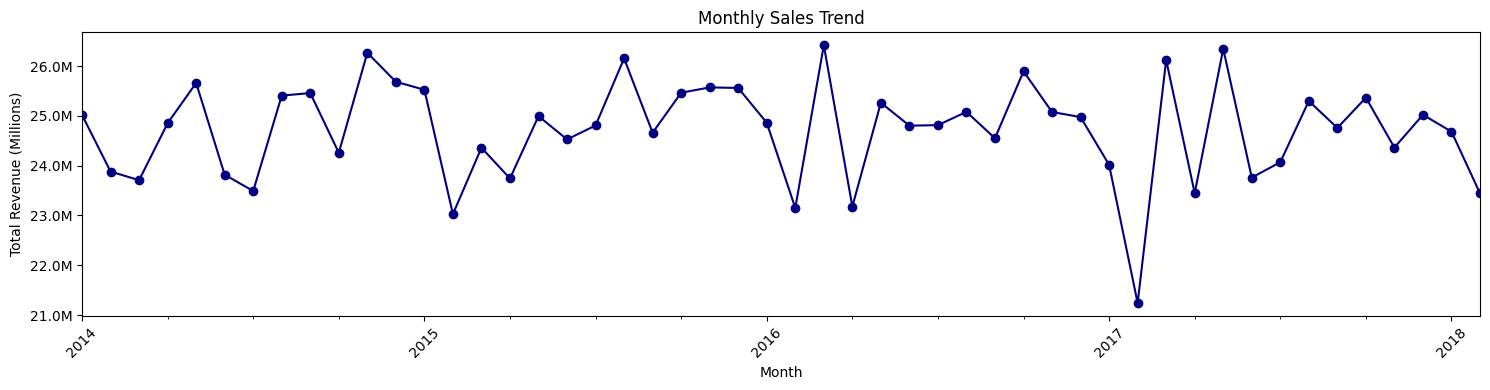

In [19]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02)
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')


plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

### INSIGHTS ---
Sales consistently cycle between \$24 M and \$26 M, with clear peaks in late spring to early summer (May–June) and troughs each January.  

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.  

## 🔹 2. *Monthly Sales Trend (All Years Combined)*

Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month

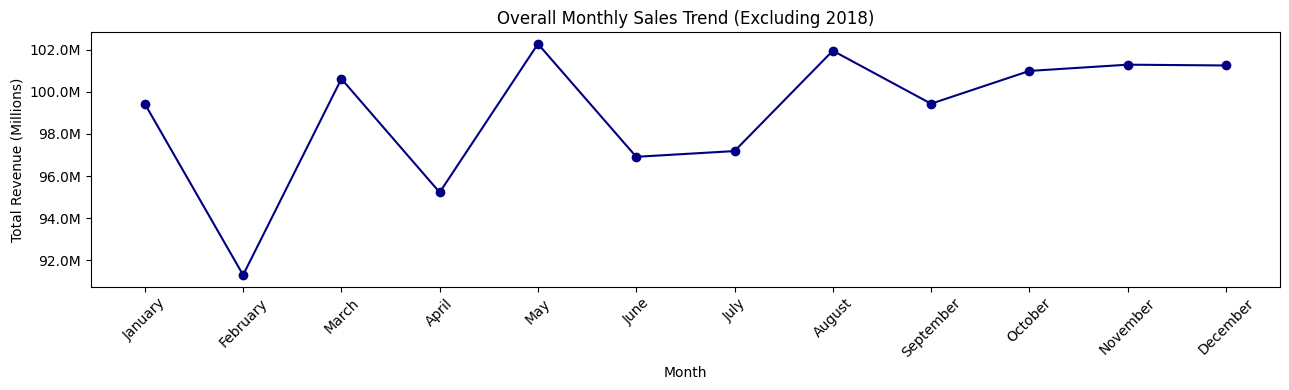

In [20]:
# 1. Filter out any 2018 orders
df_ = df[df['order_date'].dt.year != 2018]                                         
monthly_sales = (
    df_
    .groupby(['order_month_num', 'order_month_name'])['revenue']
    .sum()
    .sort_index()
)

from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales.index.get_level_values(1),  
    monthly_sales.values,                     
    marker='o',                                
    color='navy'                              
)

# 4. Scale y-axis values to millions for readability
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# 6. Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Insights

1. It shows clear seasonality with a dip in early months, two peak periods (May and August), and strong, stable performance toward the end of the year.
2. This pattern reveals a strong post–New Year surge, a spring dip, and a mid–summer bump each calendar year.
3. The mid-year period remains stable, while Q4 shows consistent high performance. From a business perspective, this helps optimize inventory, plan marketing campaigns, and improve revenue forecasting.

## 🔹 3. *Top 10 Products by Revenue (in Millions)*

Goal: Identify the highest-grossing products to focus marketing and inventory efforts

Chart: Horizontal bar chart

EDA Type: Univariate

C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\505850160.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


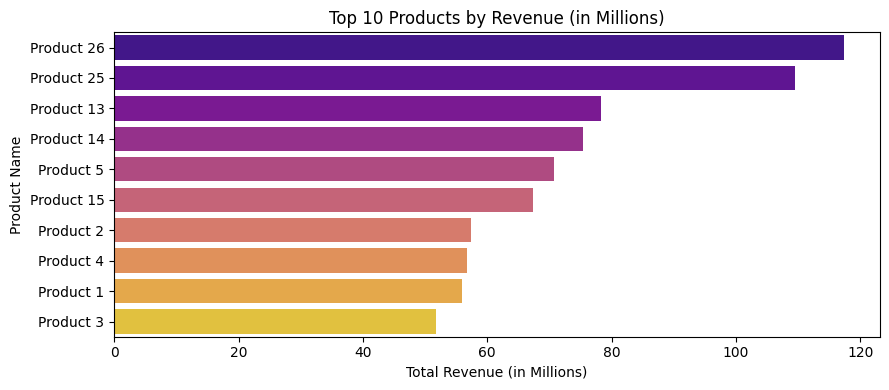

In [33]:
# Calculate total revenue for each product and convert values to millions
top_prod = df.groupby('product_name')['revenue'].sum() / 1_000_000

top_prod = top_prod.nlargest(10)
plt.figure(figsize=(9, 4))

sns.barplot(
    x=top_prod.values,    
    y=top_prod.index,     
    palette='plasma',
    legend=False    
)

plt.title('Top 10 Products by Revenue (in Millions)')  
plt.xlabel('Total Revenue (in Millions)')             
plt.ylabel('Product Name')                             

plt.tight_layout()
plt.show()

### INSIGHTS ---
Products 26 and 25 pull away at \$118 M and \$110 M, with a sharp drop to \$78 M for Product 13 and a tight mid-pack at \$68–\$75 M.  

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.  

## 🔹 4. *Top 10 Products by Avg Profit Margin*

Goal: Compare average profitability across products to identify high-margin items.

EDA: Univariate

C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\1107500538.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


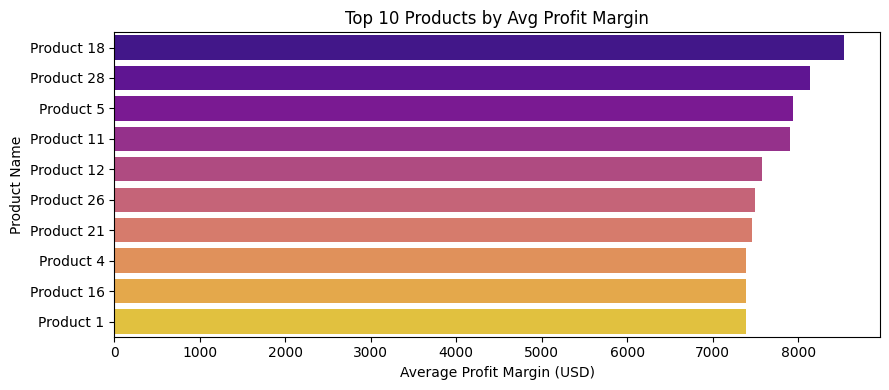

In [35]:
top_margin = (
    df.groupby('product_name')['profit']
      .mean()                        
      .sort_values(ascending=False)  
      .head(10)                      
)
plt.figure(figsize=(9, 4))
sns.barplot(
    x=top_margin.values,    
    y=top_margin.index,     
    palette='plasma'       
)

plt.title('Top 10 Products by Avg Profit Margin')  # Chart title
plt.xlabel('Average Profit Margin (USD)')          # X-axis label
plt.ylabel('Product Name')                         # Y-axis label

# 5️⃣ Adjust layout to prevent clipping and show the plot
plt.tight_layout()
plt.show()

### INSIGHTS ---

Products 18 and 28 lead with average profit margins of approximately \$8.0–8.3 K,
 followed closely by Product 5 and Product 11 around \$7.9–8.0 K.

Mid-tier performers like Products 12, 26, and 21 cluster in the \$7.7–7.8 K range, while the bottom tier (Products 4, 16, and 1) fall between \$7.4–7.6 K.

Focusing on margin optimization strategies from top performers may help elevate overall product profitability.


## 5. Sales by channel - piechart
Goal: Show distribution of total sales across channels to identify dominant sales routes

EDA Type: Univariate

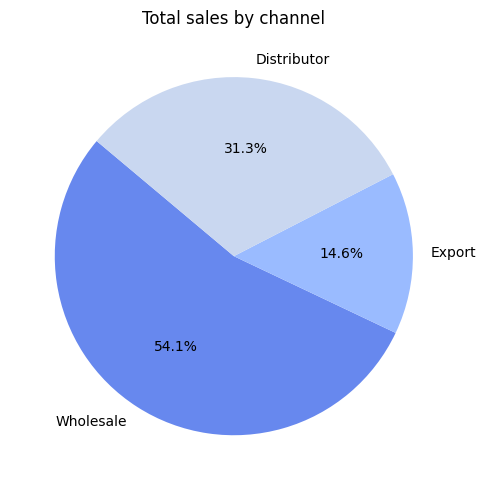

In [82]:
chan_sales = df.groupby('channel')['revenue'].sum().sort_index(ascending=False)
plt.figure(figsize=(5,5))
plt.pie(chan_sales.values,
        labels=chan_sales.index,
        colors=sns.color_palette("coolwarm"),
        startangle=140,
        autopct='%1.1f%%')

plt.title('Total sales by channel')
plt.tight_layout()
plt.show()

### INSIGHTS ---
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.  

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.  


## 6. Unit Price Distribution per product
Goal:     Compare pricing variability across different products to identify price consistency and outliers

EDA Type: Bivariate

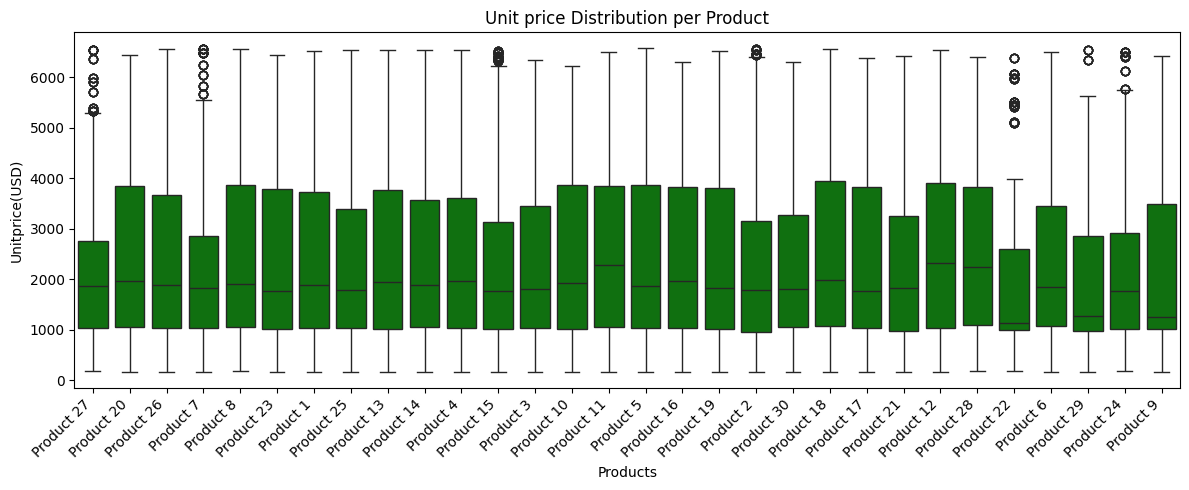

In [101]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df,
              x='product_name',
              y='unit_price',
              color='g')

plt.title('Unit price Distribution per Product')
plt.xlabel('Products')
plt.ylabel('Unitprice(USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### INSIGHTS ---
Products 8, 17, 27, 20, and 28 show high-end revenue spikes—well above their upper whiskers—likely due to bulk orders, special-edition releases, or premium bundles that temporarily inflate earnings.  

## 7. Total sales by Region(US)
**Goal:** Compare total sales across U.S. regions to identify top‑performing markets and areas for targeted growth.

**EDA Type:** Univariate comparison

C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\477180937.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


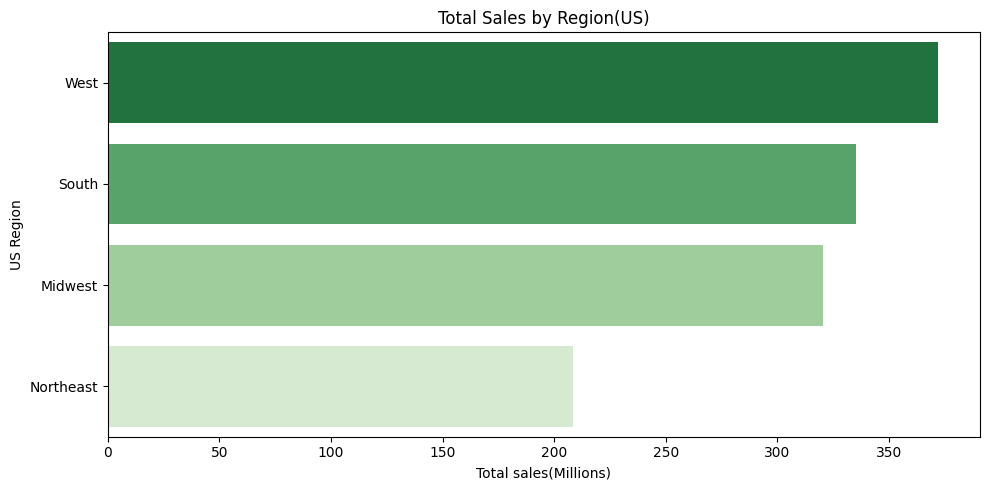

In [119]:
regional_sales = (df.groupby('us_region')['revenue'].sum().sort_values(ascending=False)/1e6)

plt.figure(figsize=(10,5))
sns.barplot(
            x=regional_sales.values,
            y=regional_sales.index,
            palette='Greens_r')

plt.title('Total Sales by Region(US)')
plt.xlabel('Total sales(Millions)')
plt.ylabel('US Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### INSIGHTS 
- **West dominates** with roughly \$360 M in sales (~35 % of total), underscoring its market leadership.  
- **South & Midwest** each contribute over \$320 M (~32 %), indicating strong, consistent demand across central regions.  
- **Northeast trails** at about \$210 M (~20 %), signaling room for growth and targeted investment.  
- **Action:** Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.  


## 8. Top and Bottom 10 Customers by revenue 

Goal: Identify highest revenue-generating states and compare their order volumes

EDA Type: Multivariate

C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\1277870831.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\1277870831.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




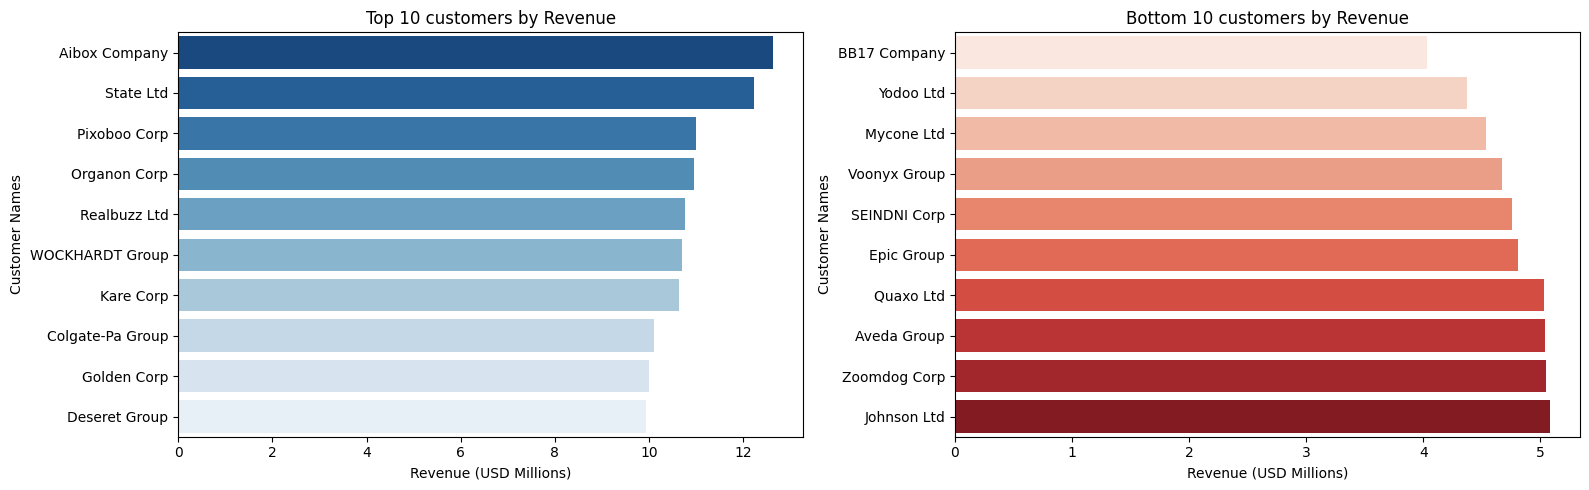

In [140]:
top_rev = (
    df.groupby('customer_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

bottom_rev = (
    df.groupby('customer_name')['revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
     x=top_rev.values /1e6,
     y=top_rev.index,
     palette='Blues_r',
     ax=axes[0]
            )

axes[0].set_title('Top 10 customers by Revenue')
axes[0].set_xlabel('Revenue (USD Millions)')
axes[0].set_ylabel('Customer Names')

sns.barplot(
    x=bottom_rev.values /1e6,
    y=bottom_rev.index,
    palette='Reds',
    ax=axes[1]
)

axes[1].set_title('Bottom 10 customers by Revenue')
axes[1].set_xlabel('Revenue (USD Millions)')
axes[1].set_ylabel('Customer Names')

plt.tight_layout()
plt.show()

### INSIGHTS ---
- Aibox Company tops the list with \$12.5 M, followed closely by State Ltd (\$12.2 M), while the 10th-ranked Deseret Group still contributes \$9.9 M—demonstrating a tight \$10–12 M top tier.

- At the bottom, Johnson Ltd leads its group with \$5.1 M, down to BB17 Company at \$4.1 M—roughly half the top customer’s revenue.

- Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.


## 9. Top and bottom 10 customers States by Revenue and order count
Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies

EDA Type: Multivariate

C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\4014345756.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




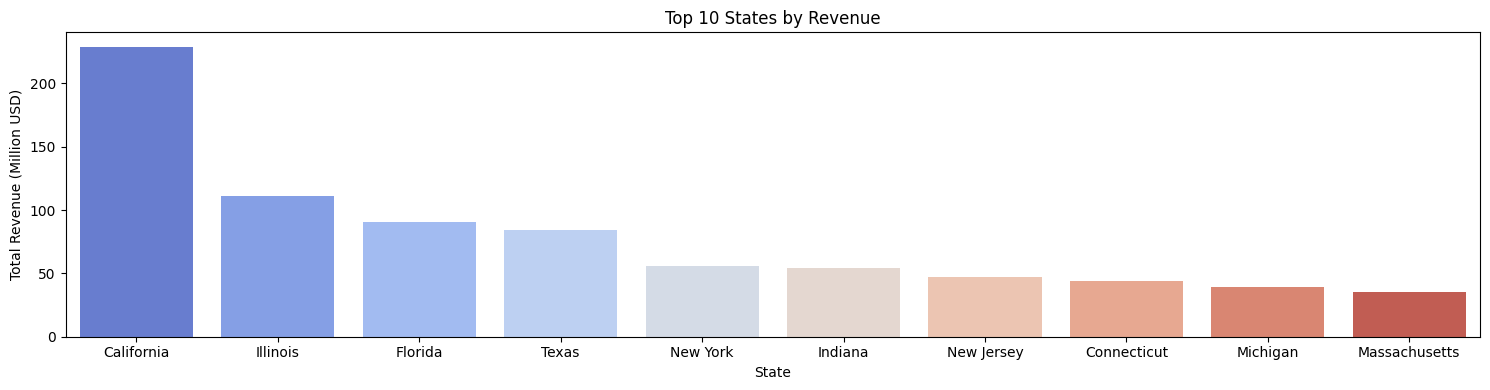

C:\Users\yuvag\AppData\Local\Temp\ipykernel_21572\4014345756.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




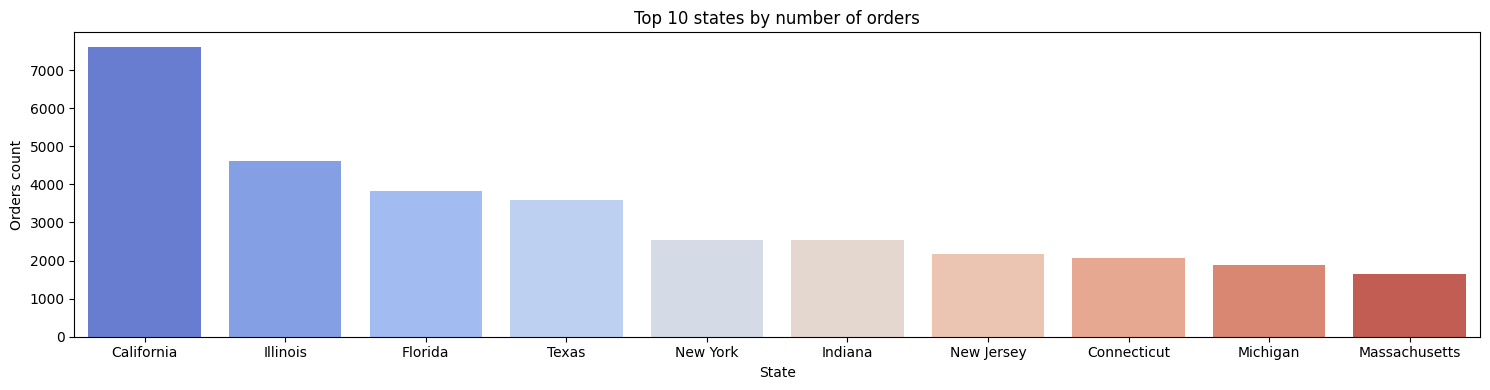

In [150]:
state_rev = df.groupby('state_name').agg(
    revenue = ('revenue', 'sum'),
    orders = ('order_number', 'nunique')
).sort_values('revenue', ascending=False).head(10)

plt.figure(figsize=(15,4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['revenue']/1e6,
    palette='coolwarm'
)
plt.title('Top 10 States by Revenue')    
plt.xlabel('State')                      
plt.ylabel('Total Revenue (Million USD)') 
plt.tight_layout()                        
plt.show() 

plt.figure(figsize=(15,4))
sns.barplot(
  x=state_rev.index,
  y=state_rev['orders'],
  palette='coolwarm'
)
plt.title('Top 10 states by number of orders')    
plt.xlabel('State')                      
plt.ylabel('Orders count') 
plt.tight_layout()                        
plt.show() 

## Insights
- California leads in both project orders and revenue across the top 10 states, showing its dominant market position. Illinois follows as a strong second in both metrics, while states like Florida, Texas, and New York trail with moderate performance. Other states such as Indiana, New Jersey, Connecticut, Michigan, and Massachusetts have significantly lower shares.

- Focus expansion on California and Illinois for quick wins, while investing in Florida and Texas for growth. Analyze per-order revenue consistency to identify pricing or upsell opportunities in laggard states like Michigan.

## 🔹 15. *Correlation Heatmap of Numeric Features*
Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

Chart: Correlation heatmap

EDA Type: Multivariate

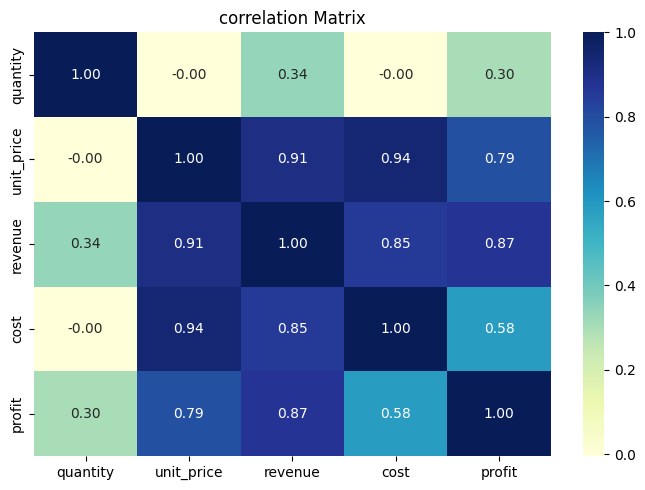

In [153]:
num_cols = ['quantity', 'unit_price', 'revenue', 'cost', 'profit']
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='YlGnBu')

plt.title('correlation Matrix')
plt.tight_layout()
plt.show()

### INSIGHTS ---
- **Profit and revenue** are very strongly correlated (0.87), indicating that as sales value increases, profit tends to rise as well.  
- **Unit price** is a key driver: it correlates 0.91 with revenue, 0.79 with profit, and 0.94 with cost—highlighting how pricing decisions ripple through both top‑line and expense figures.  
- **Cost** shows a strong link to revenue (0.85) but a more moderate tie to profit (0.58), underscoring that while higher sales often bring higher expenses, margins can still vary.  
- **Quantity** has virtually no correlation with unit price or cost (≈0.00) and only modest associations with revenue (0.34) and profit (0.30), making volume a secondary factor compared to pricing.  

# **Saving Pre-Processed Dataframe**

In [155]:
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1,2014-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,...,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2,2018-02
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,...,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2,2018-02
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,...,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2,2018-02
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,...,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2,2018-02


In [156]:
df.to_csv('EDA preprocessed Sales data.csv', index=False)

## 🔍Key Insights

1. **Revenue Trend:** 
Revenue remained stable over the years, with a noticeable drop in early 2017 that may indicate a temporary issue.

2. **Sales Channels:**  Most revenue comes from Wholesale (54%), followed by Distributors (31%), while Exports (15%) show growth potential.

3. **Product Performance:**  Top products: Product 26 ($118M) and Product 25 ($110M).
Most other products generate between $52M–$75M.

4. **Profitability:**  Profit margins range from 18% to 60%, with no clear link between price and profit and higher-priced products do not always generate higher profits.

5. **Seasonality:**  No strong seasonal pattern is observed, though a slight increase in sales occurs mid-year(May–June).

6. **Regional Performance:**  California leads with ~$230M revenue and 7500+ orders.
Other key states generate $85M–$110M, while some remain around $50M.



## 💡 Recommendations

1. **Outlier Strategy:** Exclude or formalize bulk-order and promotional SKUs when calculating averages.  
2. **Margin Uplift:** Apply top-product pricing levers to mid/low tiers; cut costs on underperformers.  
3. **Export Growth:** Invest in targeted overseas marketing and distributor partnerships.  
4. **Seasonal Planning:** Shift spend toward January trough and May–June peak; investigate the 2017 anomaly.  
